Terrain Generator
----------------------

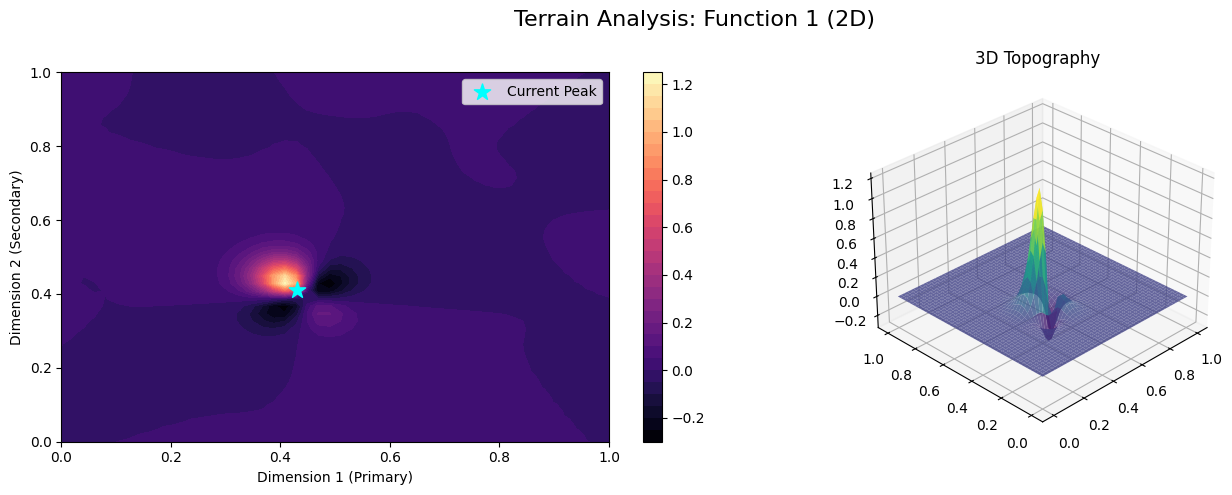

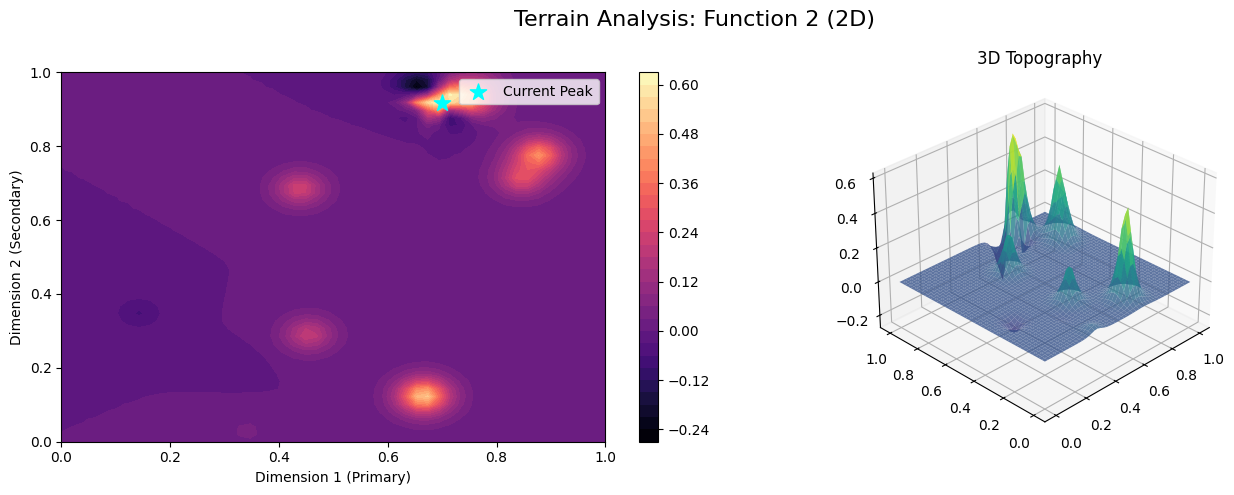

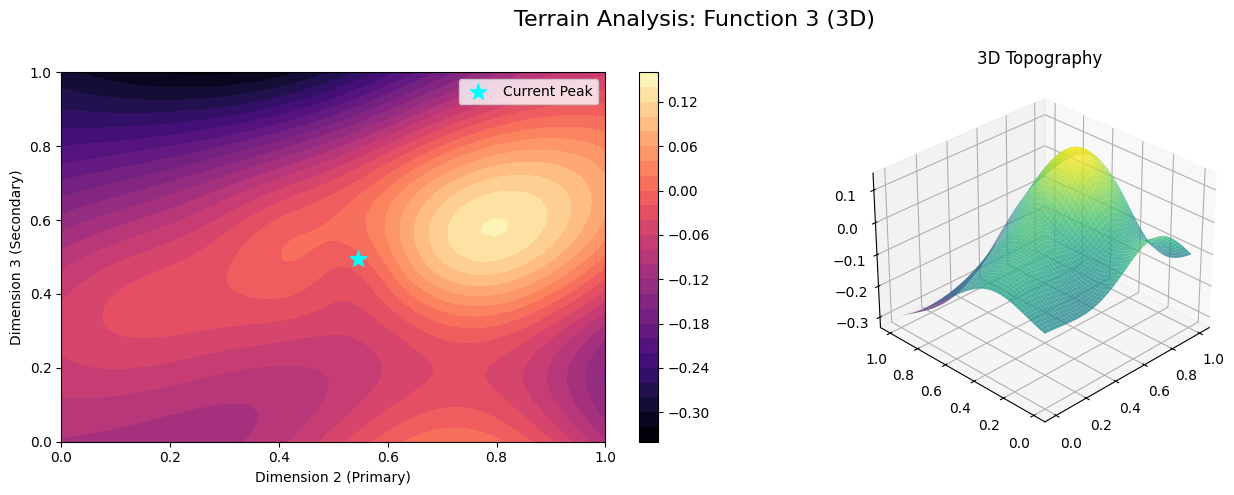

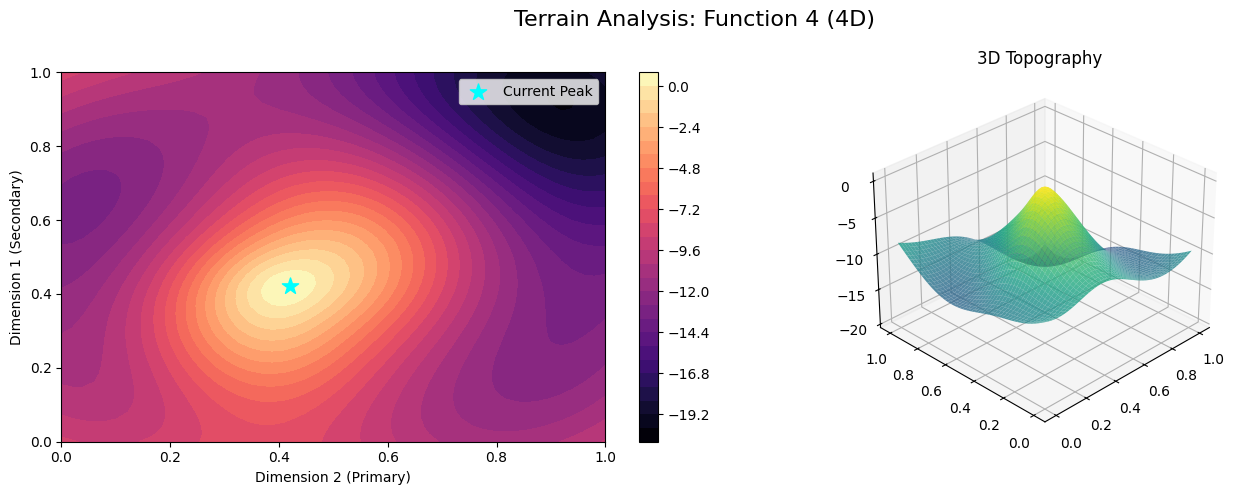

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


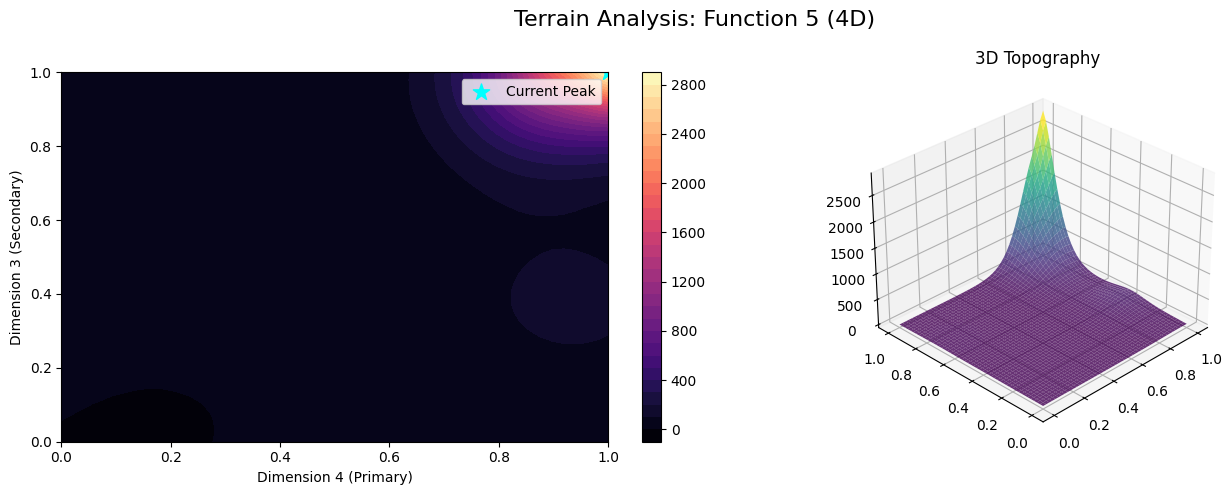

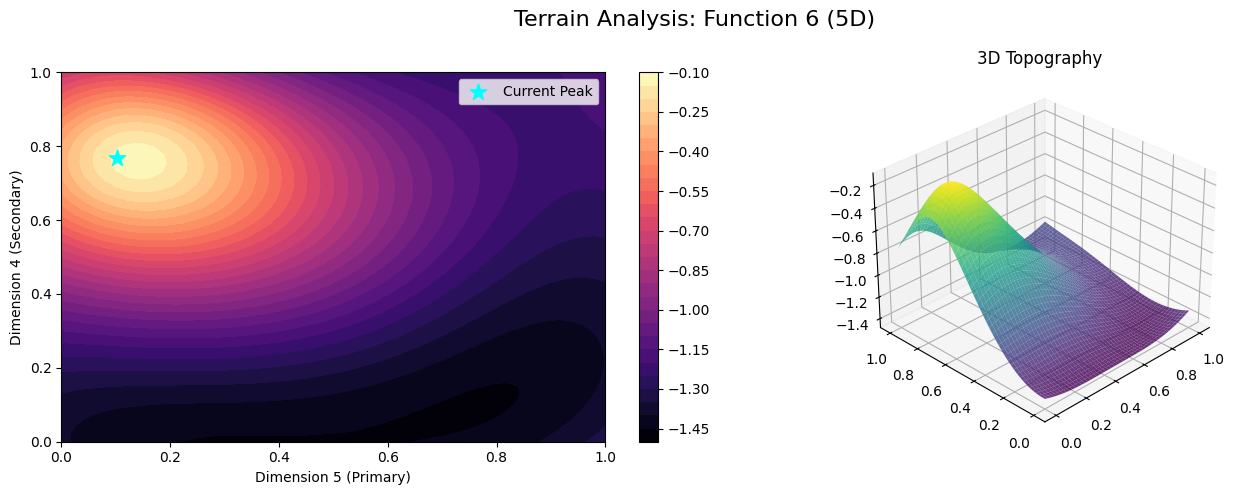

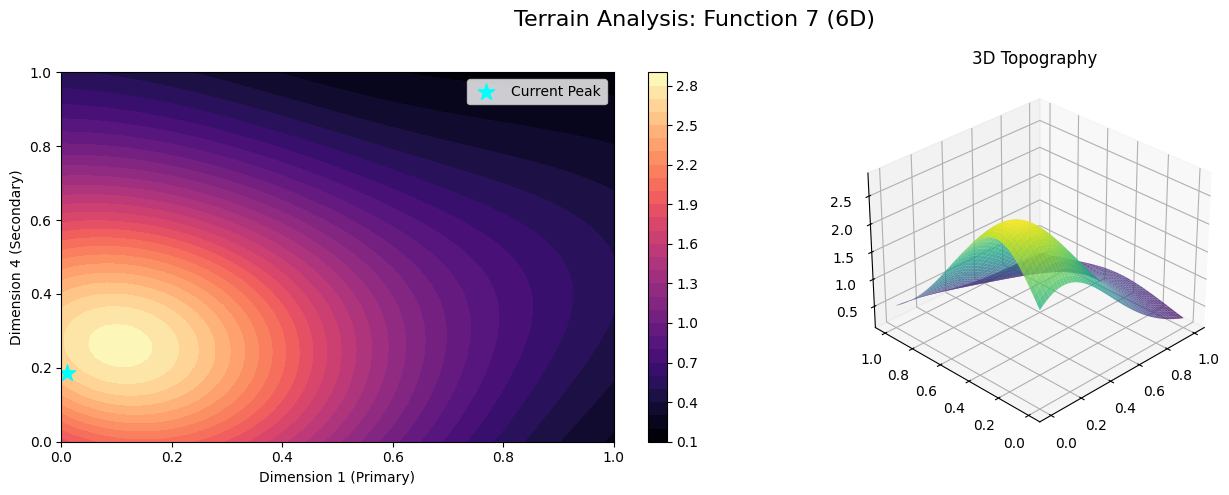

C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\hegde\anaconda3\envs\hebo_final\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://s

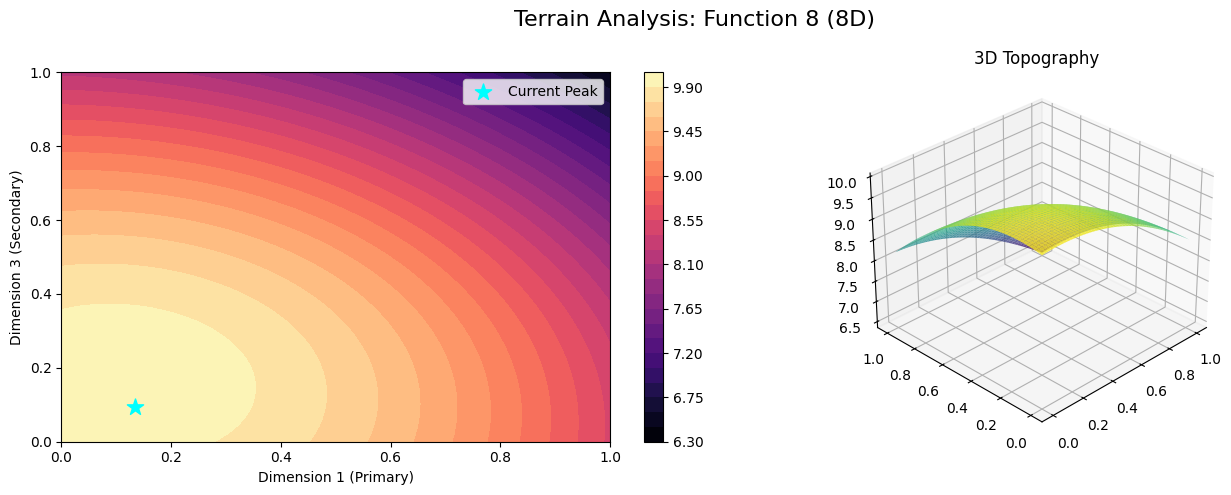

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import os

# 1. Path Configuration
BASE_DATA_DIR = os.path.join('..', 'capstone_data', 'initial_data')
VISUALS_DIR = os.path.join('..', 'visuals')
os.makedirs(VISUALS_DIR, exist_ok=True)

def get_best_dimensions(model, X):
    """
    Simulates Sensitivity Analysis by checking the impact of each 
    dimension on the GP's predicted variance across the sample space.
    Returns the indices of the two most 'active' dimensions.
    """
    dims = X.shape[1]
    if dims <= 2:
        return 0, 1 if dims == 2 else 0
    
    # Calculate standard deviation across dimensions to find 'Master Knobs'
    sensitivities = []
    for d in range(dims):
        # Measure variance of the data in this dimension as a proxy for activity
        sensitivities.append(np.var(X[:, d]))
    
    # Return indices of the top 2 most varied dimensions
    return np.argsort(sensitivities)[-2:][::-1]

def generate_all_terrains():
    for f_num in range(1, 9):
        f_name = f'function_{f_num}'
        f_path = os.path.join(BASE_DATA_DIR, f_name)
        
        # Load Data
        try:
            X = np.load(os.path.join(f_path, 'initial_inputs.npy'))
            y = np.load(os.path.join(f_path, 'initial_outputs.npy'))
        except FileNotFoundError:
            print(f"Skipping {f_name}: Files not found.")
            continue

        # Train GP Model (Matérn kernel is best for these 'cliff' terrains)
        kernel = Matern(nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
        gp.fit(X, y)

        # Sensitivity Analysis: Find the two most important dimensions
        d1, d2 = get_best_dimensions(gp, X)
        best_idx = np.argmax(y)
        best_coord = X[best_idx]

        # Create Grid for the top 2 dimensions
        res = 50
        grid_axis = np.linspace(0, 1, res)
        mesh_x, mesh_y = np.meshgrid(grid_axis, grid_axis)
        
        # Create full input matrix (slice)
        # We hold all other dimensions constant at their 'Best Known' values
        slice_input = np.tile(best_coord, (res**2, 1))
        slice_input[:, d1] = mesh_x.ravel()
        slice_input[:, d2] = mesh_y.ravel()

        # Predict Surface
        mu = gp.predict(slice_input)
        Z = mu.reshape(res, res)

        # Plotting
        fig = plt.figure(figsize=(14, 5))
        fig.suptitle(f"Terrain Analysis: Function {f_num} ({X.shape[1]}D)", fontsize=16)

        # 2D Heatmap
        ax1 = fig.add_subplot(121)
        im = ax1.contourf(mesh_x, mesh_y, Z, levels=30, cmap='magma')
        plt.colorbar(im, ax=ax1)
        ax1.scatter(best_coord[d1], best_coord[d2], color='cyan', marker='*', s=150, label='Current Peak')
        ax1.set_xlabel(f"Dimension {d1+1} (Primary)")
        ax1.set_ylabel(f"Dimension {d2+1} (Secondary)")
        ax1.legend()

        # 3D Surface
        ax2 = fig.add_subplot(122, projection='3d')
        surf = ax2.plot_surface(mesh_x, mesh_y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
        ax2.set_title("3D Topography")
        ax2.view_init(elev=30, azim=225)

        plt.tight_layout()
        plt.show() # Display to screen
        
        # Save to visuals folder
        fig.savefig(os.path.join(VISUALS_DIR, f'F{f_num}_terrain_analysis.png'))

generate_all_terrains()